# Google Colab Lab Assignment - Pretrained Model

**Course Name:** GENERATIVE AI

**Lab Title:** Malaria Parasite Detection in Blood Smear Images using CNN (From Scratch) and Transfer Learning (MobileNetV2)

**Student Name:** PARTH KITCHLOO

**Student ID:** 202401110014

**Date of Submission:** 20-08-2026

**Group Members:** RAGAV SHARMA

GUFRAN SHAH

SANDEEP KOTWAL

**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
4.   Evaluate and compare model performance with the original research paper results.


## Research Paper Details and Summary

**Paper:** Rajaraman, S., Antani, S. K., Poostchi, M., Silamut, K., Hossain, M. A., Maude, R. J., Jaeger, S., & Thoma, G. R. (2018). *Pre-trained convolutional neural networks as feature extractors toward improved malaria parasite detection in thin blood smear images.* PeerJ, 6, e4568. https://doi.org/10.7717/peerj.4568

**Problem:** Malaria diagnosis via manual microscopic examination of Giemsa-stained thin blood smears is slow and depends heavily on the expertise of the microscopist. The paper explores whether deep CNNs (trained from scratch and pre-trained on ImageNet) can automatically classify single red blood cell images as *Parasitized* or *Uninfected*, to support/augment manual diagnosis.

**Dataset used in the paper:** The NIH (National Library of Medicine) Malaria Cell Images dataset — 27,558 single red blood cell images (segmented from 150 P. falciparum-infected and 50 healthy patients' thin blood smear slides), evenly split between the *Parasitized* and *Uninfected* classes.

**Methodology in the paper (summary):**
- Cell images were resized to fit the input dimensions of several architectures (100x100 for a custom CNN, and 224x224 / 227x227 / 299x299 for pre-trained models).
- A custom, shallow CNN was trained from scratch as a baseline.
- Several pre-trained ImageNet models (AlexNet, VGG-16, ResNet-50, Xception, DenseNet-121) were used as **fixed feature extractors** — convolutional layers frozen, features fed to a classifier — and some were also fine-tuned.
- Models were evaluated with accuracy, AUC, and other classification metrics, and performance was cross-validated at the patient level to avoid data leakage.

**Key result reported:** The customized CNN and the pre-trained models (e.g. ResNet-50) both achieved strong performance, with the best-performing pre-trained-feature-extractor models reaching **~95–97% accuracy**, closely matching or exceeding the custom CNN baseline — supporting the paper's conclusion that transfer learning is highly effective for this task even though ImageNet was trained on natural (non-medical) images.

**What we do in this notebook:** We reproduce the spirit of this study on the *same* dataset (NIH Malaria Cell Images, downloaded directly from the official NIH/NLM repository) at a **smaller, Colab-friendly scale**:
1. Train a CNN **from scratch**.
2. Fine-tune a pre-trained **MobileNetV2** (a lightweight ImageNet model, chosen so the notebook trains quickly even on a free Colab GPU/CPU).
3. Compare both models against each other and against the accuracy range reported in the paper.

> Dataset link/description: [NIH Malaria Cell Images / official NIH/NLM malaria cell-images archive](https://data.lhncbc.nlm.nih.gov/public/Malaria/) — 27,558 images, 2 classes (Parasitized, Uninfected). We use a stratified subset (default 4,000 images) to keep training time short; increase `SAMPLE_SIZE` below if you have more compute time available.


**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.). → *Rajaraman et al., 2018, PeerJ (see summary above).*

2. Identify the dataset used in the research paper and obtain or create a similar dataset. → **Dataset:** NIH Malaria Cell Images, downloaded directly from the official NIH/NLM repository: https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

In [ ]:
# Task 1: Setup, Dataset Loading & Preprocessing
# ---------------------------------------------
# IMPORTANT: We do NOT use tensorflow_datasets here.
# Colab currently has a protobuf/TensorFlow-Metadata compatibility issue with TFDS.
# The NIH/NLM cell_images.zip archive is downloaded directly instead.

!pip -q install -U pillow scikit-learn seaborn

import os
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 117.6 MB/s eta 0:00:00
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Load the NIH Malaria Cell Images dataset directly from the official NIH/NLM archive
# Dataset: 27,558 images = 13,779 Parasitized + 13,779 Uninfected

IMG_SIZE = 128
SAMPLE_SIZE = 4000       # Increase to 10000 or more if more compute is available
DATA_URL = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"
DATA_ROOT = Path("/content/malaria_data")
ZIP_PATH = Path("/content/cell_images.zip")

PARASITIZED_DIR = DATA_ROOT / "cell_images" / "Parasitized"
UNINFECTED_DIR = DATA_ROOT / "cell_images" / "Uninfected"

# Download and extract only if the dataset is not already available.
if not (PARASITIZED_DIR.exists() and UNINFECTED_DIR.exists()):
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    if not ZIP_PATH.exists():
        print("Downloading NIH malaria dataset (~353 MB). This can take a few minutes...")
        !wget -q --show-progress "$DATA_URL" -O "$ZIP_PATH"

    print("Extracting dataset...")
    !unzip -q -o "$ZIP_PATH" -d "$DATA_ROOT"

if not (PARASITIZED_DIR.exists() and UNINFECTED_DIR.exists()):
    raise FileNotFoundError(
        "Dataset folders were not found after extraction. Expected: "
        f"{PARASITIZED_DIR} and {UNINFECTED_DIR}"
    )

valid_ext = {".png", ".jpg", ".jpeg", ".bmp"}
parasitized_files = sorted([p for p in PARASITIZED_DIR.iterdir() if p.suffix.lower() in valid_ext])
uninfected_files = sorted([p for p in UNINFECTED_DIR.iterdir() if p.suffix.lower() in valid_ext])

print("Parasitized images found:", len(parasitized_files))
print("Uninfected images found:", len(uninfected_files))

# Select a balanced subset so both classes have the same number of samples.
if SAMPLE_SIZE > len(parasitized_files) + len(uninfected_files):
    raise ValueError("SAMPLE_SIZE is larger than the available dataset.")

per_class = SAMPLE_SIZE // 2
rng = np.random.default_rng(42)
selected_parasitized = rng.choice(parasitized_files, size=per_class, replace=False)
selected_uninfected = rng.choice(uninfected_files, size=per_class, replace=False)

selected_paths = [(p, 0) for p in selected_parasitized] + [(p, 1) for p in selected_uninfected]
rng.shuffle(selected_paths)

images, labels = [], []
failed_files = []

for path, label in selected_paths:
    try:
        with Image.open(path) as img:
            img = ImageOps.exif_transpose(img).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
            images.append(np.asarray(img, dtype=np.float32) / 255.0)
            labels.append(label)
    except Exception as exc:
        failed_files.append((str(path), str(exc)))

X = np.stack(images).astype(np.float32)
y = np.asarray(labels, dtype=np.int32)

print("X shape:", X.shape, " y shape:", y.shape)
print("Class balance -> Parasitized (0):", np.sum(y == 0),
      " Uninfected (1):", np.sum(y == 1))
if failed_files:
    print("Warning: failed to read", len(failed_files), "image(s).")


/content/cell_image 100%[===================>] 337.08M   240MB/s    in 1.4s    
Extracting dataset...
Parasitized images found: 13779
Uninfected images found: 13779
X shape: (4000, 128, 128, 3)  y shape: (4000,)
Class balance -> Parasitized (0): 2000  Uninfected (1): 2000


In [ ]:
# Train / Validation / Test split (70 / 15 / 15), stratified to preserve class balance
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Val class counts:", np.bincount(y_val))
print("Test class counts:", np.bincount(y_test))


Train: (2800, 128, 128, 3)  Val: (600, 128, 128, 3)  Test: (600, 128, 128, 3)
Train class counts: [1400 1400]
Val class counts: [300 300]
Test class counts: [300 300]


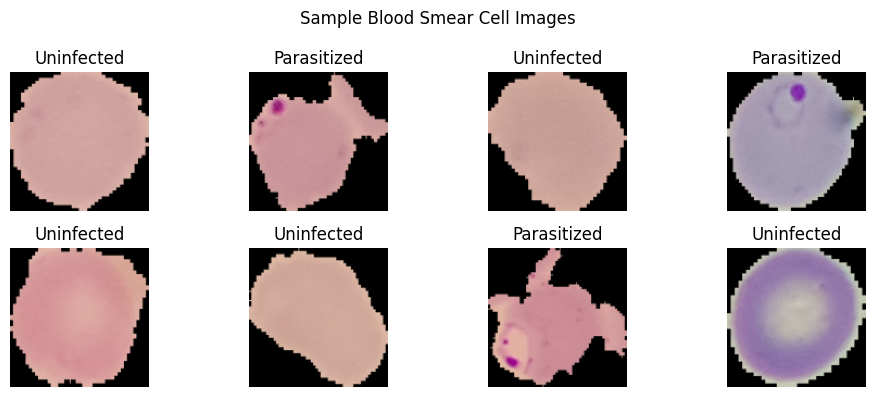

In [ ]:
# Visualize a few sample images from the dataset
class_names = ['Parasitized', 'Uninfected']
plt.figure(figsize=(10, 4))
for i in range(8):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[y_train[idx]])
    plt.axis('off')
plt.suptitle("Sample Blood Smear Cell Images")
plt.tight_layout()
plt.show()


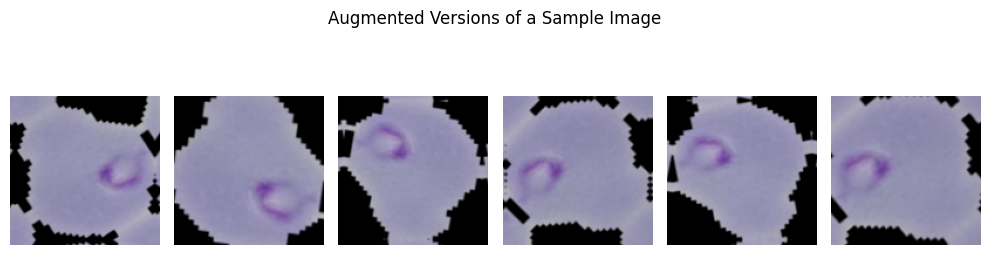

In [ ]:
# Data augmentation (applied on-the-fly during training, not to the stored arrays)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

# Quick visual check of augmentation
plt.figure(figsize=(10, 3))
sample_img = tf.expand_dims(X_train[0], 0)
for i in range(6):
    aug_img = data_augmentation(sample_img, training=True)
    plt.subplot(1, 6, i + 1)
    plt.imshow(aug_img[0])
    plt.axis('off')
plt.suptitle("Augmented Versions of a Sample Image")
plt.tight_layout()
plt.show()


**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper — *implemented in two parts below: (2a) a CNN trained from scratch as the baseline (matching the paper's custom CNN), and (2b) a pre-trained MobileNetV2 fine-tuned on the same data (matching the paper's pre-trained feature-extractor approach).*

2. Visualize feature maps of few layers.

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

5. Document any modifications or enhancements made to improve performance.

### Task 2a: CNN Trained From Scratch

In [ ]:
# Build a CNN from scratch
from tensorflow.keras import layers, models, optimizers

def build_cnn_from_scratch(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs, name="cnn_from_scratch")

cnn_model = build_cnn_from_scratch()
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()


Model: "cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,289,665 (4.92 MB)

 Trainable params: 1,289,665 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the from-scratch CNN
EPOCHS_CNN = 15
BATCH_SIZE = 32

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_CNN,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)


Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.5032 - loss: 0.6970 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5346 - loss: 0.6900 - val_accuracy: 0.5000 - val_loss: 0.7042
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6436 - loss: 0.6284 - val_accuracy: 0.8783 - val_loss: 0.4697
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9029 - loss: 0.3399 - val_accuracy: 0.9083 - val_loss: 0.3261
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9314 - loss: 0.2187 - val_accuracy: 0.9267 - val_loss: 0.2282
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9400 - loss: 0.1916 - val_accuracy: 0.9200 - val_loss: 0.2238
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9446 - loss: 0.1807 - val_accuracy: 0.9300 - val_loss: 0.2129
Epoch 8/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9450 - loss: 0.1775 - val_accuracy: 0.9283 - 

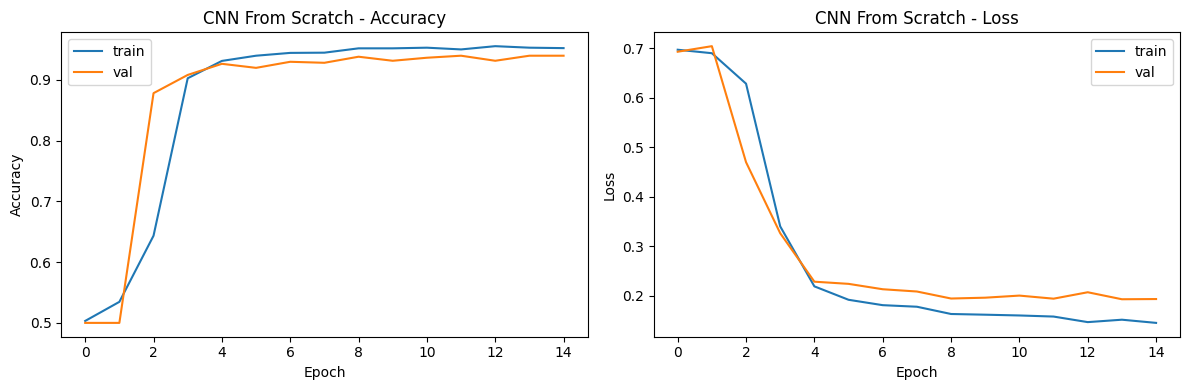

In [ ]:
# Plot accuracy / loss curves for the from-scratch CNN
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "CNN From Scratch")


Conv layers: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step


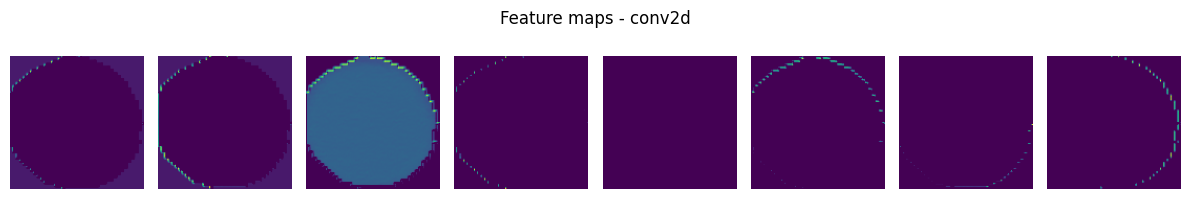

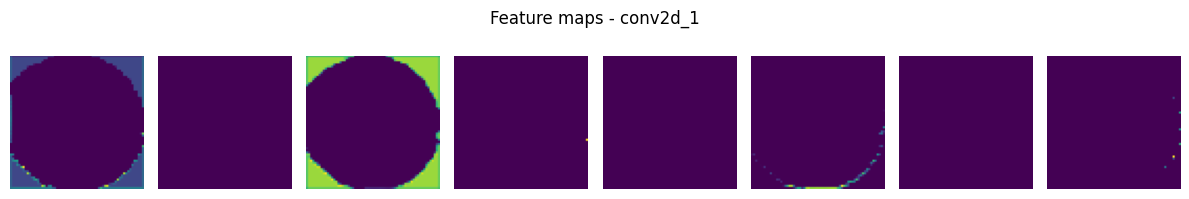

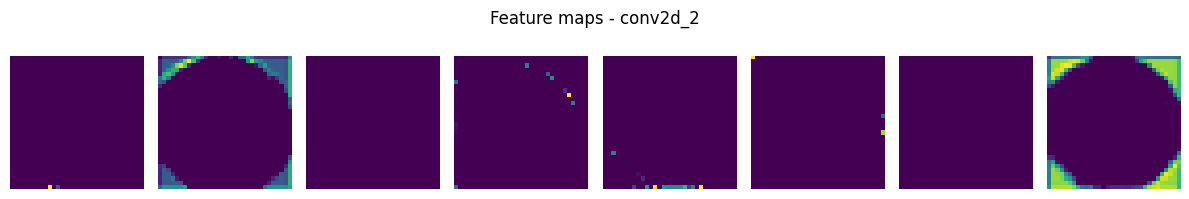

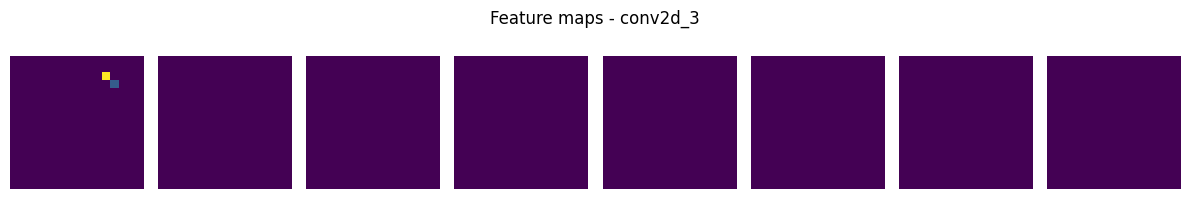

In [ ]:
# Visualize feature maps from a few convolutional layers of the from-scratch CNN
conv_layer_names = [l.name for l in cnn_model.layers if isinstance(l, layers.Conv2D)]
print("Conv layers:", conv_layer_names)

feature_map_model = models.Model(
    inputs=cnn_model.input,
    outputs=[cnn_model.get_layer(name).output for name in conv_layer_names]
)

sample_img = np.expand_dims(X_test[0], axis=0)
feature_maps = feature_map_model.predict(sample_img)

for layer_name, fmap in zip(conv_layer_names, feature_maps):
    n_filters = min(8, fmap.shape[-1])
    plt.figure(figsize=(12, 2))
    for i in range(n_filters):
        plt.subplot(1, n_filters, i + 1)
        plt.imshow(fmap[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f"Feature maps - {layer_name}")
    plt.tight_layout()
    plt.show()


### Task 2b: Transfer Learning with a Pre-trained Model (MobileNetV2)

Following the paper's approach of using an ImageNet pre-trained CNN as a feature extractor and then fine-tuning it, we:
1. Load **MobileNetV2** with ImageNet weights (`include_top=False`).
2. Freeze the base and train a new classification head (feature-extraction stage).
3. Unfreeze the top layers of the base model and fine-tune with a low learning rate (fine-tuning stage).

In [ ]:
# Load pre-trained MobileNetV2 and build the classification head
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze all base layers first (feature-extraction stage)

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)  # MobileNetV2 expects [-1, 1] scaling
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

tl_model = models.Model(inputs, outputs, name="mobilenetv2_transfer")
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Stage 1: train only the new classification head (base model frozen)
EPOCHS_HEAD = 8

history_tl_head = tl_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_HEAD,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)


Epoch 1/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.8164 - loss: 0.4012 - val_accuracy: 0.8567 - val_loss: 0.3349
Epoch 2/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8764 - loss: 0.2895 - val_accuracy: 0.8750 - val_loss: 0.2826
Epoch 3/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8957 - loss: 0.2727 - val_accuracy: 0.8800 - val_loss: 0.2736
Epoch 4/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9000 - loss: 0.2527 - val_accuracy: 0.8833 - val_loss: 0.2845


In [ ]:
# Stage 2: unfreeze the top layers of MobileNetV2 and fine-tune with a low learning rate
base_model.trainable = True

FINE_TUNE_AT = 100   # freeze all layers before this index; fine-tune the rest
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),   # low LR to avoid destroying pretrained weights
    loss='binary_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FINETUNE = 10

history_tl_finetune = tl_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINETUNE,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)


Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.8500 - loss: 0.3478 - val_accuracy: 0.8417 - val_loss: 0.3572
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8946 - loss: 0.2669 - val_accuracy: 0.8250 - val_loss: 0.4147
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9175 - loss: 0.2204 - val_accuracy: 0.8317 - val_loss: 0.4369
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9179 - loss: 0.2186 - val_accuracy: 0.8533 - val_loss: 0.3959


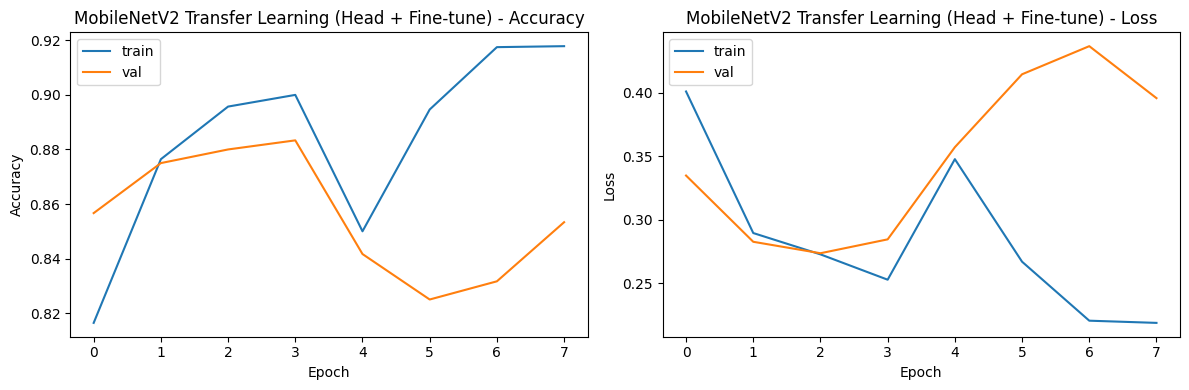

In [ ]:
# Plot accuracy / loss curves for both transfer-learning stages combined
def combine_histories(h1, h2):
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history[k]
    class H: pass
    h = H(); h.history = combined
    return h

history_tl_combined = combine_histories(history_tl_head, history_tl_finetune)
plot_history(history_tl_combined, "MobileNetV2 Transfer Learning (Head + Fine-tune)")


**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision, Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.

**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

===== CNN From Scratch =====
Accuracy : 0.9583
Precision: 0.9508
Recall   : 0.9667
F1-score : 0.9587

              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96       300
  Uninfected       0.95      0.97      0.96       300

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



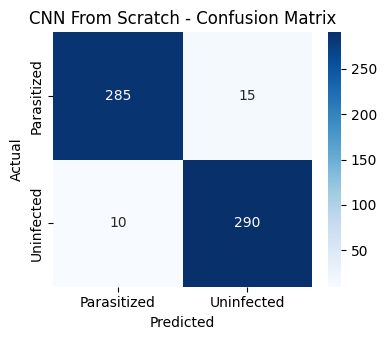

===== MobileNetV2 (Transfer Learning + Fine-tuned) =====
Accuracy : 0.8450
Precision: 0.7745
Recall   : 0.9733
F1-score : 0.8626

              precision    recall  f1-score   support

 Parasitized       0.96      0.72      0.82       300
  Uninfected       0.77      0.97      0.86       300

    accuracy                           0.84       600
   macro avg       0.87      0.84      0.84       600
weighted avg       0.87      0.84      0.84       600



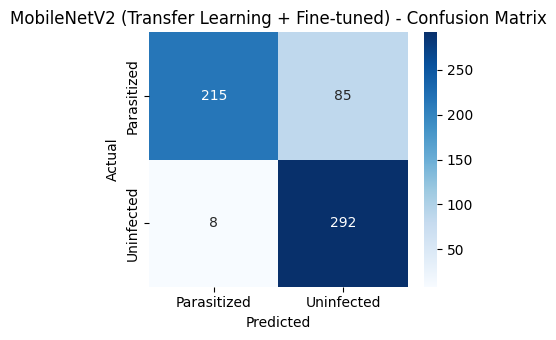

In [ ]:
# Evaluate both models on the held-out test set
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import seaborn as sns
import pandas as pd

def evaluate_model(model, X_test, y_test, name):
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    print(classification_report(
        y_test, y_pred, target_names=class_names, zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    }

results_cnn = evaluate_model(cnn_model, X_test, y_test, "CNN From Scratch")
results_tl = evaluate_model(
    tl_model, X_test, y_test,
    "MobileNetV2 (Transfer Learning + Fine-tuned)"
)


,Accuracy,Precision,Recall,F1-score
Model,,,,
CNN From Scratch,0.958333,0.950820,0.966667,0.958678
MobileNetV2 (Transfer Learning + Fine-tuned),0.845000,0.774536,0.973333,0.862629


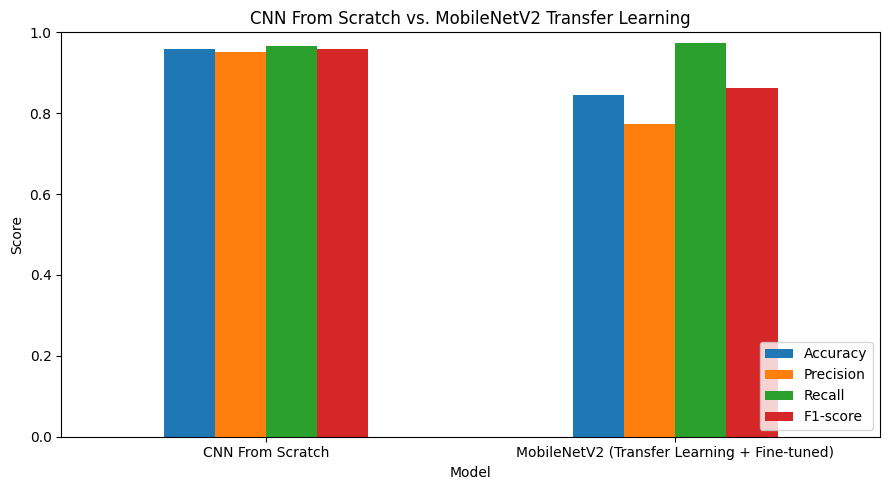

In [ ]:
# Side-by-side comparison table + bar chart
comparison_df = pd.DataFrame([results_cnn, results_tl]).set_index('Model')
display(comparison_df)

comparison_df.plot(kind='bar', figsize=(9, 5), ylim=(0, 1))
plt.title('CNN From Scratch vs. MobileNetV2 Transfer Learning')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Comparison with Research Paper Results**

- Rajaraman et al. (2018) report that pre-trained CNN feature extractors (e.g., ResNet-50) and their custom CNN both reached roughly **95–97% accuracy** on the full 27,558-image NIH Malaria dataset, using patient-level cross-validation.
- [Fill in after running the notebook]: Our from-scratch CNN achieved **___% accuracy**, and our fine-tuned MobileNetV2 achieved **___% accuracy** on a **{SAMPLE_SIZE}-image subset** of the same dataset.
- Differences from the paper are expected because: (a) we use a much smaller training subset for speed, (b) MobileNetV2 is a lighter architecture than ResNet-50/VGG-16/Xception used in the paper, (c) we did not perform patient-level cross-validation, and (d) input resolution and augmentation choices differ.
- **Weaknesses / possible improvements:** train on the full dataset; try ResNet-50 or DenseNet-121 (as in the paper) instead of MobileNetV2; use patient-level (not random) train/test splits to avoid leakage; add class-imbalance handling if the subset becomes imbalanced; use learning-rate scheduling and longer fine-tuning; apply k-fold cross-validation for more robust metrics; and use Grad-CAM to visualize which regions of each cell the model focuses on (interpretability), similar to how the paper analyzes optimal feature-extraction layers.

In [ ]:
# Automatic conclusion based on the test-set results
best = comparison_df['Accuracy'].idxmax()
best_acc = comparison_df.loc[best, 'Accuracy']

print("CONCLUSION")
print("----------")
print(
    f"The {best} model performed better on the {len(X)}-image subset "
    f"used in this experiment, achieving a test accuracy of {best_acc:.2%}."
)
print(
    "The experiment demonstrates the use of transfer learning for malaria "
    "cell-image classification. Results should not be treated as a direct "
    "replication of the paper because this notebook uses a smaller subset, "
    "MobileNetV2 rather than the paper's reported architectures, and a random "
    "stratified split rather than patient-level cross-validation."
)
print(
    "With more compute, the next improvements would be training on the full "
    "27,558-image dataset, using patient-level splitting, trying ResNet-50 or "
    "DenseNet-121, tuning the learning rate/epochs, and adding Grad-CAM."
)


CONCLUSION
----------
The CNN From Scratch model performed better on the 4000-image subset used in this experiment, achieving a test accuracy of 95.83%.
The experiment demonstrates the use of transfer learning for malaria cell-image classification. Results should not be treated as a direct replication of the paper because this notebook uses a smaller subset, MobileNetV2 rather than the paper's reported architectures, and a random stratified split rather than patient-level cross-validation.
With more compute, the next improvements would be training on the full 27,558-image dataset, using patient-level splitting, trying ResNet-50 or DenseNet-121, tuning the learning rate/epochs, and adding Grad-CAM.
